In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from src.data.eda import load_processed_dataset, load_tiff_as_dataarray, infer_temporal_resolution_from_metadata
from src.split.spatial import make_stratified_spatial_split, save_spatial_split
from src.split.export_tabular import export_train_test_split

In [2]:
# CONFIGURACIÓN

processed_base_dir = Path("/home/dani/github/profecia/data/processed")
masks_dir = Path("/home/dani/github/profecia/data/masks")
splits_base_dir = Path("/home/dani/github/profecia/data/splits")

VARIABLE_NAMES = ["LAI", "SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]
PREDICTOR_NAMES = ["SM1", "SM2", "TP", "T2M", "SSRD", "VPD"]

# Selector principal
temporal_resolution = "annual"   # "monthly" o "annual"
input_dir = processed_base_dir / temporal_resolution

# Máscara categórica para estratificar
MASK_TYPE = "landcover"  # "climate" o "landcover"

# Submuestreo espacial previo al split
pixel_fraction = 0.5  # del total de píxeles, el 50% se selecciona aleatoriamente para el split  
test_fraction = 0.10     # del subconjunto ya seleccionado, 10% a test
seed = 42
subset_seed = 42
ignore_codes = (0,)
min_valid_fraction = 0.0 

if MASK_TYPE == "climate":
    MASK_TIFF = masks_dir / "climate" / "Beck_KG_V1_present_0p5_5climates.tif"
    LABELS = {
        0: "NoData",
        1: "Tropical",
        2: "Arid",
        3: "Temperate",
        4: "Cold",
        5: "Polar",
    }

elif MASK_TYPE == "landcover":
    MASK_TIFF = masks_dir / "land_cover" / "GLASS-GLC_7classes_2000_0p5_dominant.tif"
    LABELS = {
        0: "NoData",
        10: "Cropland",
        20: "Forest",
        30: "Grassland",
        40: "Shrubland",
        70: "Tundra",
        90: "Barren land",
        100: "Snow/Ice",
    }

else:
    raise ValueError("MASK_TYPE debe ser 'climate' o 'landcover'")

# Guardado separado por resolución temporal y tipo de máscara
split_name = f"{MASK_TYPE}_{temporal_resolution}_split"
SPLITS_DIR = splits_base_dir / temporal_resolution / MASK_TYPE
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

print("input_dir  :", input_dir)
print("MASK_TYPE  :", MASK_TYPE)
print("MASK_TIFF  :", MASK_TIFF)
print("SPLITS_DIR :", SPLITS_DIR)
print("pixel_fraction:", pixel_fraction)
print("test_fraction :", test_fraction)

input_dir  : /home/dani/github/profecia/data/processed/annual
MASK_TYPE  : landcover
MASK_TIFF  : /home/dani/github/profecia/data/masks/land_cover/GLASS-GLC_7classes_2000_0p5_dominant.tif
SPLITS_DIR : /home/dani/github/profecia/data/splits/annual/landcover
pixel_fraction: 0.5
test_fraction : 0.1


In [3]:
data_dict, metadata = load_processed_dataset(
    input_dir=input_dir,
    variable_names=VARIABLE_NAMES,
    reference_variable="LAI",
)

lai = data_dict["LAI"]
predictors = {name: data_dict[name] for name in PREDICTOR_NAMES}

loaded_temporal_resolution = infer_temporal_resolution_from_metadata(metadata, "LAI")

print("Variables cargadas:", list(data_dict.keys()))
print("Shape LAI:", lai.shape)
print("Dims LAI:", lai.dims)
print("Periodo:", str(lai.time.min().values)[:10], "->", str(lai.time.max().values)[:10])
print("Lat:", float(lai.latitude.min()), "->", float(lai.latitude.max()))
print("Lon:", float(lai.longitude.min()), "->", float(lai.longitude.max()))
print("Temporal resolution metadata:", loaded_temporal_resolution)

assert loaded_temporal_resolution == temporal_resolution, (
    f"La resolución cargada ({loaded_temporal_resolution}) no coincide con "
    f"la solicitada ({temporal_resolution})."
)

Variables cargadas: ['LAI', 'SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD']
Shape LAI: (41, 360, 720)
Dims LAI: ('time', 'latitude', 'longitude')
Periodo: 1982-01-01 -> 2022-01-01
Lat: -90.0 -> 89.5
Lon: -180.0 -> 179.5
Temporal resolution metadata: annual


## Cargar la máscara

In [4]:
category_mask = load_tiff_as_dataarray(
    tiff_path=MASK_TIFF,
    latitude=lai.latitude.values,
    longitude=lai.longitude.values,
    name=f"{MASK_TYPE}_mask",
)

print(category_mask)
print("Clases presentes:", np.unique(category_mask.values[~np.isnan(category_mask.values)]).astype(int))

<xarray.DataArray 'landcover_mask' (latitude: 360, longitude: 720)> Size: 259kB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(360, 720), dtype=uint8)
Coordinates:
  * latitude   (latitude) float32 1kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Clases presentes: [  0  10  20  30  40  70  90 100]


## Crear split espacial estratificado con submuestreo

In [5]:
split_result = make_stratified_spatial_split(
    lai=lai,
    category_mask=category_mask,
    test_fraction=test_fraction,
    seed=seed,
    ignore_codes=ignore_codes,
    split_name=split_name,
    category_labels=LABELS,
    pixel_fraction=pixel_fraction,
    subset_seed=subset_seed,
    min_valid_fraction=min_valid_fraction,
)

train_mask = split_result["train_mask"]
test_mask = split_result["test_mask"]
selected_pixel_mask = split_result["selected_pixel_mask"]
eligible_pixel_mask = split_result["eligible_pixel_mask"]
valid_pixel_mask = split_result["valid_pixel_mask"]
split_metadata = split_result["metadata"]

## Resumen por categoría

In [7]:
subset_summary_df = pd.DataFrame(split_metadata["pixel_subset_per_category"])
split_summary_df = pd.DataFrame(split_metadata["split_per_category"])

print("Submuestreo espacial previo")
display(subset_summary_df)

print("\n Split train/test sobre píxeles seleccionados")
display(split_summary_df)

Submuestreo espacial previo


,category_code,category_label,n_eligible,n_selected,n_dropped,pixel_fraction_real
0,10,Cropland,6029,3014,3015,0.499917
1,20,Forest,20037,10018,10019,0.499975
2,30,Grassland,11282,5641,5641,0.500000
3,40,Shrubland,6740,3370,3370,0.500000
4,70,Tundra,6630,3315,3315,0.500000
5,90,Barren land,12329,6164,6165,0.499959
6,100,Snow/Ice,958,479,479,0.500000



 Split train/test sobre píxeles seleccionados


,category_code,category_label,n_selected,n_test,n_train,test_fraction_real
0,10,Cropland,3014,301,2713,0.099867
1,20,Forest,10018,1002,9016,0.100020
2,30,Grassland,5641,564,5077,0.099982
3,40,Shrubland,3370,337,3033,0.100000
4,70,Tundra,3315,332,2983,0.100151
5,90,Barren land,6164,616,5548,0.099935
6,100,Snow/Ice,479,48,431,0.100209


## Validaciones del split

In [8]:
assert train_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])
assert test_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])
assert selected_pixel_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])
assert eligible_pixel_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])
assert valid_pixel_mask.shape == (lai.sizes["latitude"], lai.sizes["longitude"])

assert not np.any(train_mask.values & test_mask.values), "Train y test no deben solaparse"

covered = train_mask.values | test_mask.values
selected = selected_pixel_mask.values.astype(bool)
eligible = eligible_pixel_mask.values.astype(bool)

assert np.array_equal(covered, selected), "Train + test no cubren exactamente los píxeles seleccionados"
assert np.all(selected <= eligible), "selected_pixel_mask contiene píxeles no elegibles"

print("Split correcto")
print("Valid pixels   :", int(valid_pixel_mask.values.sum()))
print("Eligible pixels:", int(eligible_pixel_mask.values.sum()))
print("Selected pixels:", int(selected_pixel_mask.values.sum()))
print("Train pixels   :", int(train_mask.values.sum()))
print("Test pixels    :", int(test_mask.values.sum()))

Split correcto
Valid pixels   : 64274
Eligible pixels: 64005
Selected pixels: 32001
Train pixels   : 28801
Test pixels    : 3200


## Guardar máscaras y metadata del split

In [9]:
save_spatial_split(
    output_dir=SPLITS_DIR,
    train_mask=train_mask,
    test_mask=test_mask,
    metadata=split_metadata,
    prefix=MASK_TYPE,
    selected_pixel_mask=selected_pixel_mask,
    eligible_pixel_mask=eligible_pixel_mask,
    valid_pixel_mask=valid_pixel_mask,
)

print("Split guardado en:", SPLITS_DIR)

Split guardado en: /home/dani/github/profecia/data/splits/annual/landcover


## Visualización rápida del subset y del test

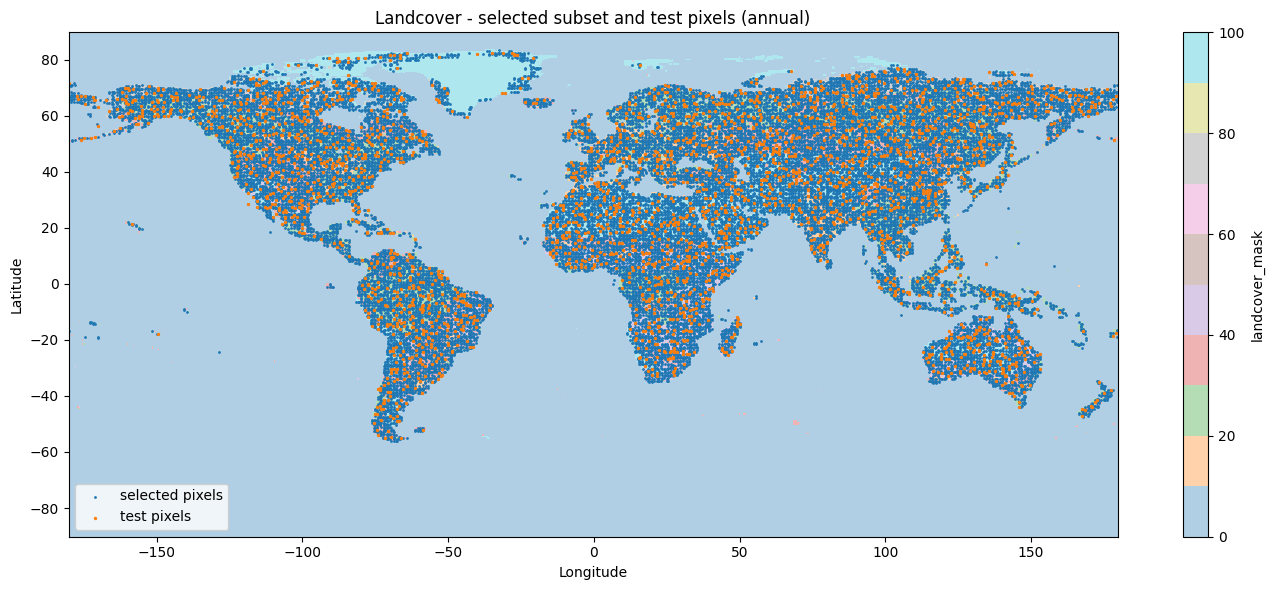

In [10]:
plt.figure(figsize=(14, 6))

category_mask.plot(
    x="longitude",
    y="latitude",
    cmap="tab10",
    alpha=0.35,
    add_colorbar=True,
)

sel_lat_idx, sel_lon_idx = np.where(selected_pixel_mask.values)
sel_lats = selected_pixel_mask.latitude.values[sel_lat_idx]
sel_lons = selected_pixel_mask.longitude.values[sel_lon_idx]

test_lat_idx, test_lon_idx = np.where(test_mask.values)
test_lats = test_mask.latitude.values[test_lat_idx]
test_lons = test_mask.longitude.values[test_lon_idx]

plt.scatter(sel_lons, sel_lats, s=1, label="selected pixels")
plt.scatter(test_lons, test_lats, s=2, label="test pixels")
plt.title(f"{MASK_TYPE.capitalize()} - selected subset and test pixels ({temporal_resolution})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()

## Exportar train/test tabular a `.npy`

In [11]:
dataset_metadata = export_train_test_split(
    target=lai,
    predictors=predictors,
    train_mask=train_mask,
    test_mask=test_mask,
    output_dir=SPLITS_DIR,
    prefix=f"{MASK_TYPE}_{temporal_resolution}",
    lat_block_size=10,
)

dataset_metadata

{'prefix': 'landcover_annual',
 'n_train': 1175123,
 'n_test': 130572,
 'n_features': 6,
 'feature_names': ['SM1', 'SM2', 'TP', 'T2M', 'SSRD', 'VPD'],
 'target': 'LAI',
 'target_dtype': 'float32',
 'feature_dtypes': {'SM1': 'float32',
  'SM2': 'float32',
  'TP': 'float32',
  'T2M': 'float32',
  'SSRD': 'float32',
  'VPD': 'float32'},
 'n_time': 41,
 'time_start': '1982-01-01 00:00:00',
 'time_end': '2022-01-01 00:00:00',
 'time_values': ['1982-01-01 00:00:00',
  '1983-01-01 00:00:00',
  '1984-01-01 00:00:00',
  '1985-01-01 00:00:00',
  '1986-01-01 00:00:00',
  '1987-01-01 00:00:00',
  '1988-01-01 00:00:00',
  '1989-01-01 00:00:00',
  '1990-01-01 00:00:00',
  '1991-01-01 00:00:00',
  '1992-01-01 00:00:00',
  '1993-01-01 00:00:00',
  '1994-01-01 00:00:00',
  '1995-01-01 00:00:00',
  '1996-01-01 00:00:00',
  '1997-01-01 00:00:00',
  '1998-01-01 00:00:00',
  '1999-01-01 00:00:00',
  '2000-01-01 00:00:00',
  '2001-01-01 00:00:00',
  '2002-01-01 00:00:00',
  '2003-01-01 00:00:00',
  '2004-01

## Cargar arrays exportados y revisar shapes

In [12]:
X_train = np.load(SPLITS_DIR / "X_train.npy", mmap_mode="r")
y_train = np.load(SPLITS_DIR / "y_train.npy", mmap_mode="r")

X_test = np.load(SPLITS_DIR / "X_test.npy", mmap_mode="r")
y_test = np.load(SPLITS_DIR / "y_test.npy", mmap_mode="r")

pixel_id_test = np.load(SPLITS_DIR / "pixel_id_test.npy", mmap_mode="r")
lat_idx_test = np.load(SPLITS_DIR / "lat_idx_test.npy", mmap_mode="r")
lon_idx_test = np.load(SPLITS_DIR / "lon_idx_test.npy", mmap_mode="r")
time_idx_test = np.load(SPLITS_DIR / "time_idx_test.npy", mmap_mode="r")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("pixel_id_test:", pixel_id_test.shape)
print("lat_idx_test :", lat_idx_test.shape)
print("lon_idx_test :", lon_idx_test.shape)
print("time_idx_test:", time_idx_test.shape)

X_train: (1175123, 6)
y_train: (1175123,)
X_test : (130572, 6)
y_test : (130572,)
pixel_id_test: (130572,)
lat_idx_test : (130572,)
lon_idx_test : (130572,)
time_idx_test: (130572,)


In [13]:
assert X_train.shape[0] == y_train.shape[0], "X_train e y_train no cuadran"
assert X_test.shape[0] == y_test.shape[0], "X_test e y_test no cuadran"

assert X_test.shape[0] == pixel_id_test.shape[0]
assert X_test.shape[0] == lat_idx_test.shape[0]
assert X_test.shape[0] == lon_idx_test.shape[0]
assert X_test.shape[0] == time_idx_test.shape[0]

assert X_train.shape[1] == len(PREDICTOR_NAMES)
assert X_test.shape[1] == len(PREDICTOR_NAMES)

print("Arrays exportados consistentes")

Arrays exportados consistentes


In [14]:
print("NaN X_train:", np.isnan(X_train).sum())
print("NaN y_train:", np.isnan(y_train).sum())

print("NaN X_test :", np.isnan(X_test).sum())
print("NaN y_test :", np.isnan(y_test).sum())

assert np.isnan(X_train).sum() == 0
assert np.isnan(y_train).sum() == 0
assert np.isnan(X_test).sum() == 0
assert np.isnan(y_test).sum() == 0

print("No hay NaN en los arrays exportados")

NaN X_train: 0
NaN y_train: 0
NaN X_test : 0
NaN y_test : 0
No hay NaN en los arrays exportados


## Trazabilidad temporal del test

In [15]:
with open(SPLITS_DIR / "dataset_metadata.json", "r", encoding="utf-8") as f:
    exported_metadata = json.load(f)

time_values = pd.to_datetime(exported_metadata["time_values"])

print("Temporal resolution inferred:", exported_metadata["temporal_resolution_inferred"])
print("time_start:", exported_metadata["time_start"])
print("time_end  :", exported_metadata["time_end"])
print("n_time    :", exported_metadata["n_time"])

# ejemplo: reconstruir las observaciones del primer píxel de test
if len(pixel_id_test) > 0:
    first_pixel_id = int(pixel_id_test[0])

    df_first_pixel = pd.DataFrame({
        "pixel_id": np.asarray(pixel_id_test),
        "lat_idx": np.asarray(lat_idx_test),
        "lon_idx": np.asarray(lon_idx_test),
        "time_idx": np.asarray(time_idx_test),
        "y_true": np.asarray(y_test),
    })

    df_first_pixel = df_first_pixel[df_first_pixel["pixel_id"] == first_pixel_id].copy()
    df_first_pixel["time"] = time_values[df_first_pixel["time_idx"].values]
    df_first_pixel = df_first_pixel.sort_values("time").reset_index(drop=True)

    print(f"Primer pixel_id de test: {first_pixel_id}")
    display(df_first_pixel.head(20))
else:
    print("No hay observaciones de test.")

Temporal resolution inferred: annual
time_start: 1982-01-01 00:00:00
time_end  : 2022-01-01 00:00:00
n_time    : 41
Primer pixel_id de test: 50617


,pixel_id,lat_idx,lon_idx,time_idx,y_true,time
0,50617,70,217,0,0.800000,1982-01-01
1,50617,70,217,1,0.802778,1983-01-01
2,50617,70,217,2,0.799074,1984-01-01
3,50617,70,217,3,0.801852,1985-01-01
4,50617,70,217,4,0.801852,1986-01-01
5,50617,70,217,5,0.800926,1987-01-01
6,50617,70,217,6,0.801852,1988-01-01
7,50617,70,217,7,0.799074,1989-01-01
8,50617,70,217,8,0.798148,1990-01-01
9,50617,70,217,9,0.800926,1991-01-01
